# Heart Disease Risk Screening: Home Check + Clinic Mode

**Goal:** predict whether a patient has heart disease (`num > 0`) using two models:
- **Home model:** only easy-to-know inputs (a patient can fill it in at home)
- **Clinic model:** adds ECG and exercise-test values (a nurse can collect these)

**Important:** in healthcare, missing a sick patient is worse than a false alarm, so we focus on **recall** and **ROC-AUC**, not just accuracy.

Put `heart_disease_uci.csv` in the same folder as this notebook, then run the cells from top to bottom.

## 1. Imports and settings

In [3]:
import warnings, json, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, recall_score, precision_score,
                             accuracy_score, f1_score)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_style("whitegrid")
os.makedirs("models", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

## 2. Load the data and look at it

In [4]:
df = pd.read_csv("heart_disease_uci.csv")
print("Shape:", df.shape)
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
print(df.dtypes)
print()
print("Missing values (count and %):")
missing = pd.DataFrame({"missing": df.isnull().sum(), "percent": (df.isnull().mean() * 100).round(1)})
missing[missing["missing"] > 0].sort_values("missing", ascending=False)

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

Missing values (count and %):


,missing,percent
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
exang,55,6.0
thalch,55,6.0
chol,30,3.3
restecg,2,0.2


In [6]:
df.describe().T
df.info()
print()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB

Duplicate rows: 0


## 3. Cleaning

Problems found in this dataset:
1. `chol` and `trestbps` contain **0**, which is impossible for a living patient. These are hidden missing values, so we turn them into `NaN`.
2. `id` is only a row number, so we drop it.
3. `ca` and `thal` are more than 50% missing, and a home user or basic clinic cannot provide them, so we do not use them.
4. The target `num` is 0 to 4. We turn it into **0 = no disease, 1 = disease**.

In [7]:
data = df.copy()

# 1. Impossible zeros -> missing
print("chol == 0 :", (data["chol"] == 0).sum(), "| trestbps == 0 :", (data["trestbps"] == 0).sum())
data.loc[data["chol"] == 0, "chol"] = np.nan
data.loc[data["trestbps"] == 0, "trestbps"] = np.nan

# 2. Drop id
data = data.drop(columns=["id"])

# 3. Binary target
data["target"] = (data["num"] > 0).astype(int)

# 4. Make True/False columns into text categories (keeps missing as NaN)
for c in ["fbs", "exang"]:
    data[c] = data[c].map({True: "True", False: "False"}).astype(object)
    data[c] = data[c].where(data[c].notna(), np.nan)

print("\nTarget balance:")
print(data["target"].value_counts())
print(data["target"].value_counts(normalize=True).round(3))

chol == 0 : 172 | trestbps == 0 : 1

Target balance:
target
1    509
0    411
Name: count, dtype: int64
target
1    0.553
0    0.447
Name: proportion, dtype: float64


In [8]:
print(data[["chol", "trestbps"]].describe().T[["count", "min"]])
print(data[["fbs", "exang"]].isnull().sum())
data.head()

          count   min
chol      718.0  85.0
trestbps  860.0  80.0
fbs      90
exang    55
dtype: int64


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


## 4. Exploratory Data Analysis (EDA)

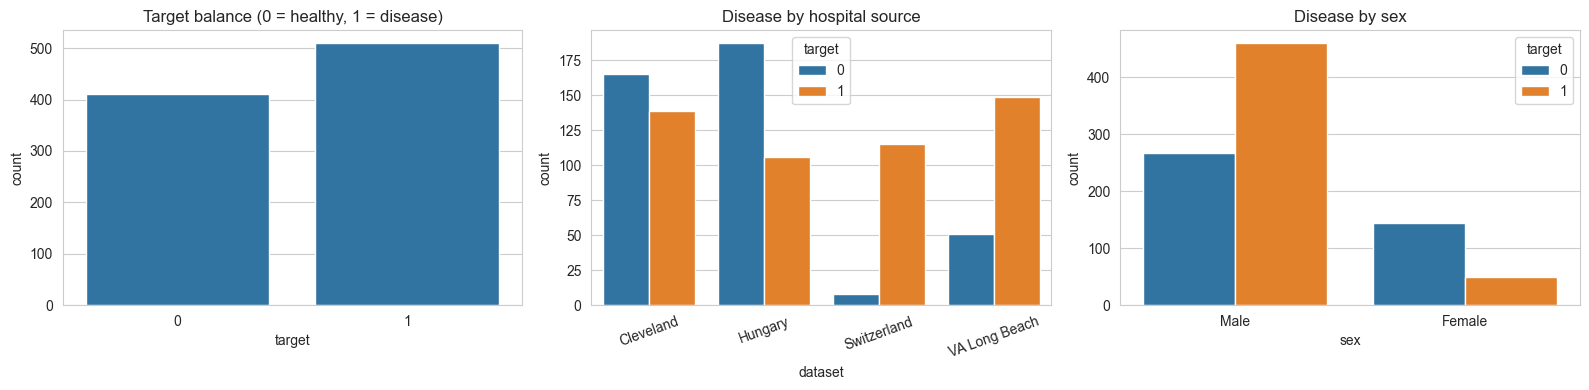

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="target", data=data, ax=axes[0])
axes[0].set_title("Target balance (0 = healthy, 1 = disease)")

sns.countplot(x="dataset", hue="target", data=data, ax=axes[1])
axes[1].set_title("Disease by hospital source")
axes[1].tick_params(axis="x", rotation=20)

sns.countplot(x="sex", hue="target", data=data, ax=axes[2])
axes[2].set_title("Disease by sex")

plt.tight_layout()
plt.savefig("reports/figures/eda_overview.png", dpi=120)
plt.show()

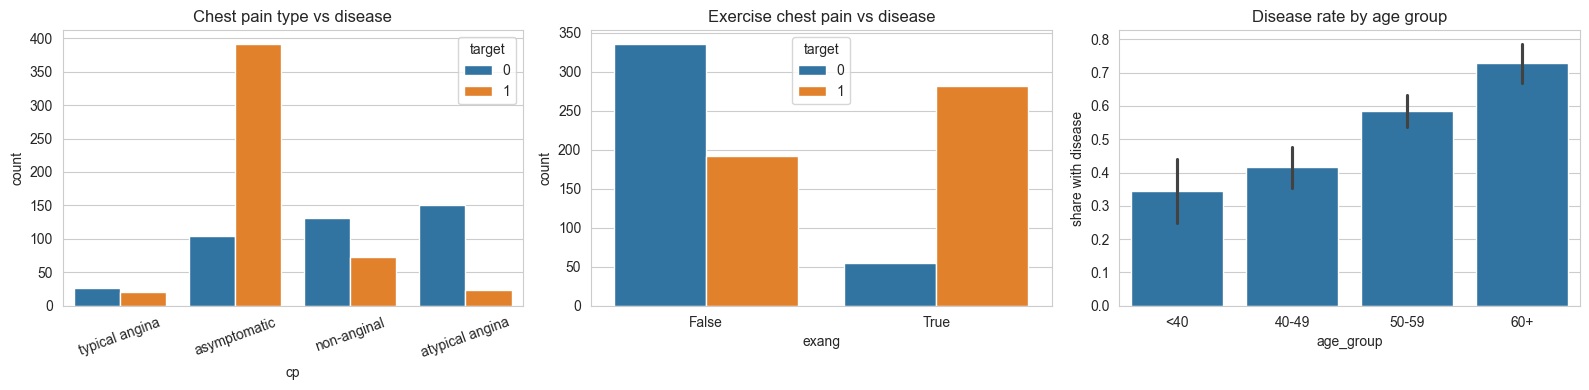

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="cp", hue="target", data=data, ax=axes[0])
axes[0].set_title("Chest pain type vs disease")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(x="exang", hue="target", data=data, ax=axes[1])
axes[1].set_title("Exercise chest pain vs disease")

data["age_group"] = pd.cut(data["age"], bins=[0, 40, 50, 60, 100], labels=["<40", "40-49", "50-59", "60+"])
sns.barplot(x="age_group", y="target", data=data, ax=axes[2])
axes[2].set_title("Disease rate by age group")
axes[2].set_ylabel("share with disease")

plt.tight_layout()
plt.savefig("reports/figures/eda_features.png", dpi=120)
plt.show()

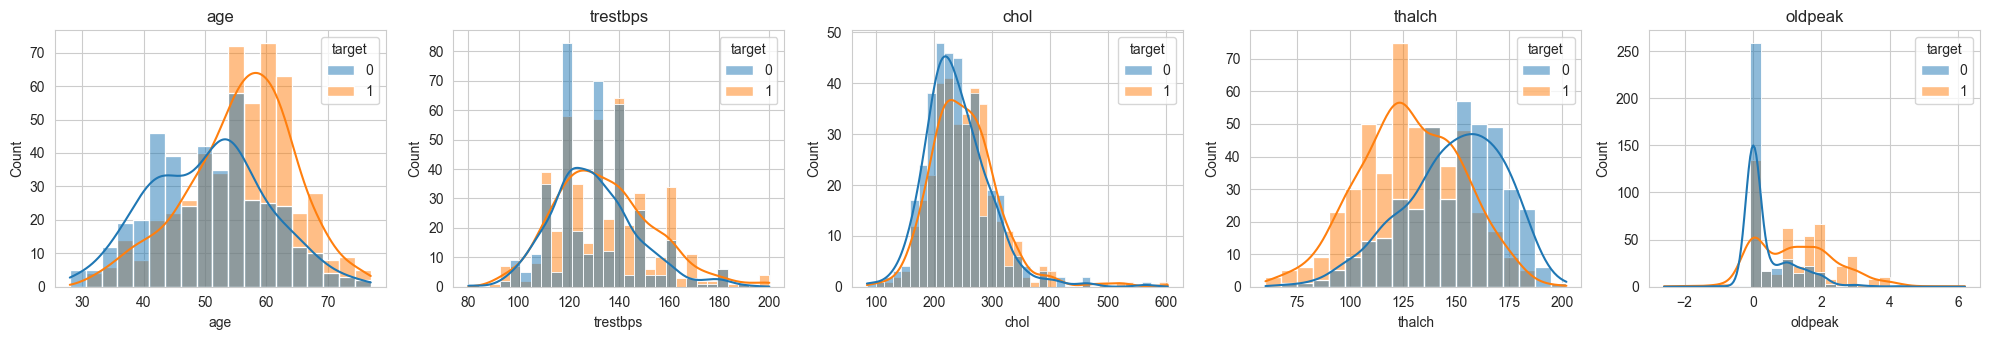

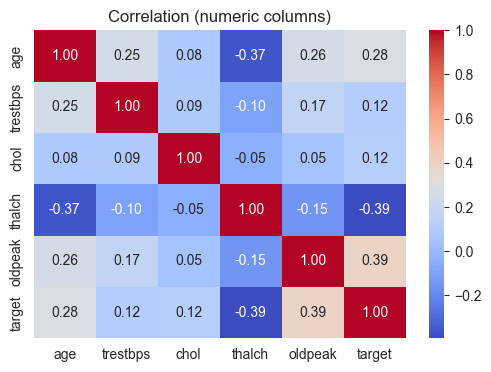

In [11]:
num_cols_all = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, col in zip(axes, num_cols_all):
    sns.histplot(data=data, x=col, hue="target", kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(data[num_cols_all + ["target"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation (numeric columns)")
plt.show()

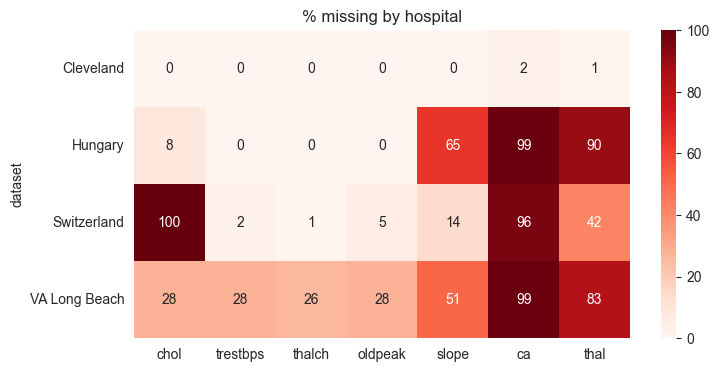

In [12]:
# Missing values by hospital (shows why the hospital source matters)
missing_by_hosp = data.groupby("dataset")[["chol", "trestbps", "thalch", "oldpeak", "slope", "ca", "thal"]].apply(lambda g: g.isnull().mean() * 100).round(0)
plt.figure(figsize=(8, 4))
sns.heatmap(missing_by_hosp, annot=True, fmt=".0f", cmap="Reds")
plt.title("% missing by hospital")
plt.show()

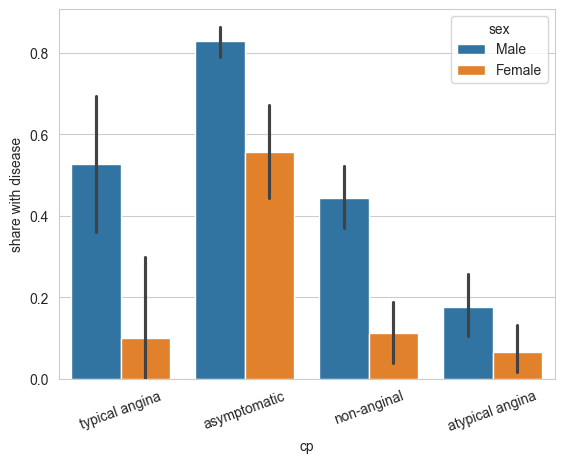

In [13]:
# Disease rate by sex and chest pain together
sns.barplot(x="cp", y="target", hue="sex", data=data)
plt.xticks(rotation=20)
plt.ylabel("share with disease")
plt.show()

**Write your own insights here** (2 to 3 lines each, in plain English). Examples to look for:
- Which chest pain type has the highest disease rate?
- How does disease rate change with age?
- Which hospital has the most missing data?

## 5. Choose the features for each mode

| Mode | Features |
|---|---|
| **Home** | age, sex, chest pain type, resting blood pressure, exercise chest pain, cholesterol (optional), fasting sugar (optional) |
| **Clinic** | Home features + resting ECG, max heart rate, ST depression (`oldpeak`), ST slope |

`ca` and `thal` are left out because they are too often missing and need special tests.

In [14]:
HOME_FEATURES = ["age", "sex", "cp", "trestbps", "exang", "chol", "fbs"]
CLINIC_FEATURES = HOME_FEATURES + ["restecg", "thalch", "oldpeak", "slope"]

NUMERIC_POSSIBLE = ["age", "trestbps", "chol", "thalch", "oldpeak"]

def make_preprocessor(features):
    num = [c for c in features if c in NUMERIC_POSSIBLE]
    cat = [c for c in features if c not in NUMERIC_POSSIBLE]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([("num", num_pipe, num), ("cat", cat_pipe, cat)])

print("Home features  :", HOME_FEATURES)
print("Clinic features:", CLINIC_FEATURES)

Home features  : ['age', 'sex', 'cp', 'trestbps', 'exang', 'chol', 'fbs']
Clinic features: ['age', 'sex', 'cp', 'trestbps', 'exang', 'chol', 'fbs', 'restecg', 'thalch', 'oldpeak', 'slope']


In [16]:
prep = make_preprocessor(HOME_FEATURES)
sample = prep.fit_transform(data[HOME_FEATURES])
print("Rows, columns after preparation:", sample.shape)
print(prep.get_feature_names_out())

Rows, columns after preparation: (920, 13)
['num__age' 'num__trestbps' 'num__chol' 'cat__sex_Female' 'cat__sex_Male'
 'cat__cp_asymptomatic' 'cat__cp_atypical angina' 'cat__cp_non-anginal'
 'cat__cp_typical angina' 'cat__exang_False' 'cat__exang_True'
 'cat__fbs_False' 'cat__fbs_True']


## 6. Train/test split (no data leakage)

We split **first**. All imputing and scaling happens inside a `Pipeline`, so the test data never influences training.

In [15]:
y = data["target"]

X_home = data[HOME_FEATURES]
X_clinic = data[CLINIC_FEATURES]

# Same split (same rows) for both modes so results are comparable
idx_train, idx_test = train_test_split(data.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

Xh_train, Xh_test = X_home.loc[idx_train], X_home.loc[idx_test]
Xc_train, Xc_test = X_clinic.loc[idx_train], X_clinic.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

print("Train:", len(idx_train), "| Test:", len(idx_test))
print("Disease share  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: 736 | Test: 184
Disease share  train: 0.553  test: 0.554


In [18]:
strat = data["sex"] + "_" + data["target"].astype(str)
idx_train, idx_test = train_test_split(data.index, test_size=0.2, stratify=strat, random_state=RANDOM_STATE)

## 7. Compare several models with cross-validation

We use 5-fold stratified cross-validation on the training set only. We report the mean and the standard deviation of each score.

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "recall": "recall", "precision": "precision", "f1": "f1", "roc_auc": "roc_auc"}

def compare_models(features, X_train, y_train):
    rows = []
    for name, model in models.items():
        pipe = Pipeline([("prep", make_preprocessor(features)), ("model", model)])
        res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
        row = {"Model": name}
        for m in scoring:
            row[m] = f"{res['test_' + m].mean():.3f} ± {res['test_' + m].std():.3f}"
        row["_auc"] = res["test_roc_auc"].mean()
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("_auc", ascending=False)
    return out

print("=== HOME MODE ===")
home_results = compare_models(HOME_FEATURES, Xh_train, y_train)
display(home_results.drop(columns="_auc").set_index("Model"))

print("=== CLINIC MODE ===")
clinic_results = compare_models(CLINIC_FEATURES, Xc_train, y_train)
display(clinic_results.drop(columns="_auc").set_index("Model"))

=== HOME MODE ===


,accuracy,recall,precision,f1,roc_auc
Model,,,,,
Logistic Regression,0.776 ± 0.025,0.818 ± 0.066,0.790 ± 0.039,0.801 ± 0.025,0.861 ± 0.027
Random Forest,0.780 ± 0.023,0.825 ± 0.062,0.791 ± 0.038,0.805 ± 0.024,0.847 ± 0.027
SVM,0.772 ± 0.033,0.845 ± 0.066,0.772 ± 0.046,0.803 ± 0.028,0.839 ± 0.029
Gradient Boosting,0.758 ± 0.022,0.820 ± 0.058,0.766 ± 0.043,0.789 ± 0.018,0.837 ± 0.030
KNN,0.765 ± 0.042,0.840 ± 0.042,0.766 ± 0.057,0.799 ± 0.028,0.829 ± 0.041


=== CLINIC MODE ===


,accuracy,recall,precision,f1,roc_auc
Model,,,,,
Logistic Regression,0.794 ± 0.018,0.838 ± 0.055,0.803 ± 0.041,0.817 ± 0.016,0.872 ± 0.020
SVM,0.811 ± 0.037,0.894 ± 0.023,0.796 ± 0.050,0.841 ± 0.023,0.869 ± 0.028
Random Forest,0.804 ± 0.025,0.855 ± 0.047,0.808 ± 0.045,0.829 ± 0.018,0.864 ± 0.030
Gradient Boosting,0.806 ± 0.032,0.855 ± 0.034,0.809 ± 0.046,0.830 ± 0.023,0.856 ± 0.023
KNN,0.802 ± 0.039,0.870 ± 0.019,0.796 ± 0.049,0.830 ± 0.026,0.850 ± 0.031


## 8. Tune the best model

We tune a Random Forest and a Gradient Boosting model for each mode, using ROC-AUC, and keep the better one.

In [20]:
param_grids = {
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [200, 400], "model__max_depth": [4, 6, None], "model__min_samples_leaf": [1, 3, 5]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.03, 0.1], "model__max_depth": [2, 3]},
    ),
}

def tune(features, X_train, y_train):
    best = None
    for name, (model, grid) in param_grids.items():
        pipe = Pipeline([("prep", make_preprocessor(features)), ("model", model)])
        gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
        gs.fit(X_train, y_train)
        print(f"  {name:18s} best CV ROC-AUC = {gs.best_score_:.3f}  params = {gs.best_params_}")
        if best is None or gs.best_score_ > best[1]:
            best = (gs.best_estimator_, gs.best_score_, name)
    print("  -> Chosen:", best[2])
    return best[0]

print("HOME MODE")
home_model = tune(HOME_FEATURES, Xh_train, y_train)
print("CLINIC MODE")
clinic_model = tune(CLINIC_FEATURES, Xc_train, y_train)

HOME MODE
  Random Forest      best CV ROC-AUC = 0.860  params = {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
  Gradient Boosting  best CV ROC-AUC = 0.856  params = {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}
  -> Chosen: Random Forest
CLINIC MODE
  Random Forest      best CV ROC-AUC = 0.873  params = {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
  Gradient Boosting  best CV ROC-AUC = 0.863  params = {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}
  -> Chosen: Random Forest


## 9. Choose the decision threshold (recall first)

The default threshold is 0.5. For screening we want to **catch most sick patients**, so we pick the highest threshold that still gives at least **90% recall** on cross-validated training predictions. We never use the test set to choose it.

In [21]:
TARGET_RECALL = 0.90

def pick_threshold(model, X_train, y_train, target_recall=TARGET_RECALL):
    proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    best_t = 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        if recall_score(y_train, (proba >= t).astype(int)) >= target_recall:
            best_t = t
    return round(float(best_t), 2)

thr_home = pick_threshold(home_model, Xh_train, y_train)
thr_clinic = pick_threshold(clinic_model, Xc_train, y_train)
print("Home threshold  :", thr_home)
print("Clinic threshold:", thr_clinic)

Home threshold  : 0.43
Clinic threshold: 0.44


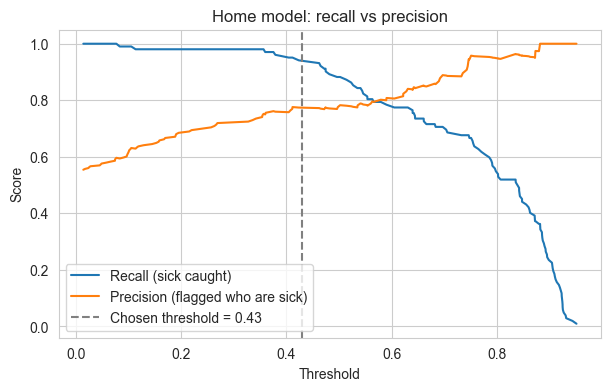

In [24]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_home)

plt.figure(figsize=(7, 4))
plt.plot(thresholds, recall[:-1], label="Recall (sick caught)")
plt.plot(thresholds, precision[:-1], label="Precision (flagged who are sick)")
plt.axvline(thr_home, color="gray", linestyle="--", label=f"Chosen threshold = {thr_home}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Home model: recall vs precision")
plt.legend()
plt.show()

## 10. Final evaluation on the untouched test set

===== Home model (threshold = 0.43) =====
              precision    recall  f1-score   support

  No disease       0.89      0.66      0.76        82
     Disease       0.77      0.93      0.84       102

    accuracy                           0.81       184
   macro avg       0.83      0.79      0.80       184
weighted avg       0.82      0.81      0.80       184

ROC-AUC: 0.896


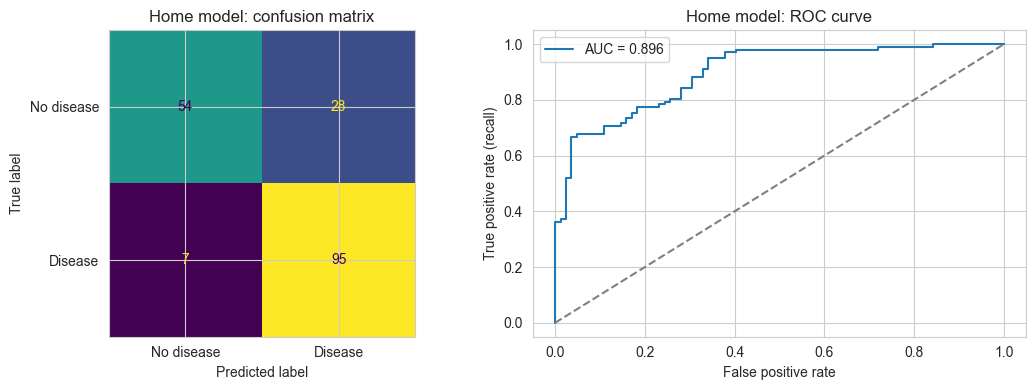

===== Clinic model (threshold = 0.44) =====
              precision    recall  f1-score   support

  No disease       0.86      0.70      0.77        82
     Disease       0.79      0.91      0.85       102

    accuracy                           0.82       184
   macro avg       0.83      0.80      0.81       184
weighted avg       0.82      0.82      0.81       184

ROC-AUC: 0.906


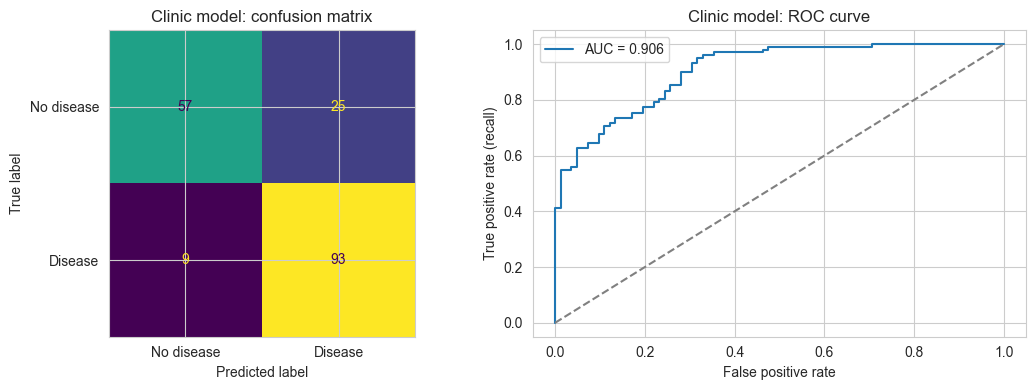

In [25]:
def evaluate(name, model, X_train, X_test, y_test, threshold):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f"===== {name} (threshold = {threshold}) =====")
    print(classification_report(y_test, pred, target_names=["No disease", "Disease"]))
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["No disease", "Disease"]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{name}: confusion matrix")
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate (recall)")
    axes[1].set_title(f"{name}: ROC curve"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"reports/figures/eval_{name.lower().replace(' ', '_')}.png", dpi=120)
    plt.show()
    return proba

proba_home = evaluate("Home model", home_model, Xh_train, Xh_test, y_test, thr_home)
proba_clinic = evaluate("Clinic model", clinic_model, Xc_train, Xc_test, y_test, thr_clinic)

In [26]:
summary = pd.DataFrame({
    "Model": ["Home", "Clinic"],
    "Accuracy": [accuracy_score(y_test, proba_home >= thr_home), accuracy_score(y_test, proba_clinic >= thr_clinic)],
    "Recall": [recall_score(y_test, proba_home >= thr_home), recall_score(y_test, proba_clinic >= thr_clinic)],
    "Precision": [precision_score(y_test, proba_home >= thr_home), precision_score(y_test, proba_clinic >= thr_clinic)],
    "F1": [f1_score(y_test, proba_home >= thr_home), f1_score(y_test, proba_clinic >= thr_clinic)],
    "ROC-AUC": [roc_auc_score(y_test, proba_home), roc_auc_score(y_test, proba_clinic)],
}).round(3)
summary.set_index("Model")

,Accuracy,Recall,Precision,F1,ROC-AUC
Model,,,,,
Home,0.810,0.931,0.772,0.844,0.896
Clinic,0.815,0.912,0.788,0.845,0.906


## 11. Explainability: which features matter?

Permutation importance shows how much the score drops when one feature is shuffled. A bigger drop means a more important feature.

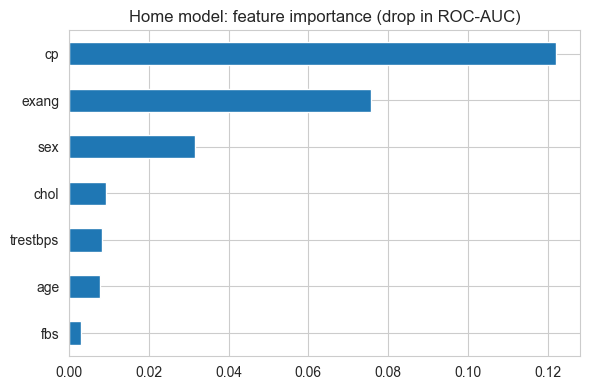

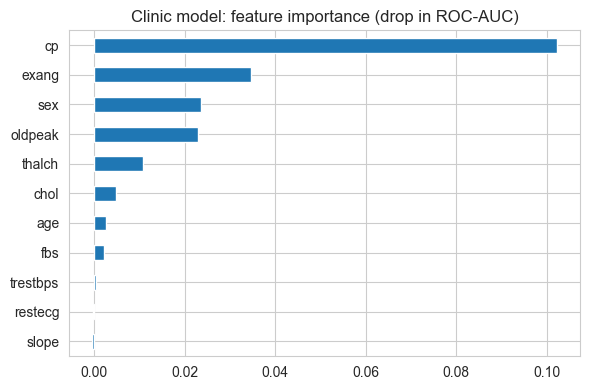

In [27]:
def plot_importance(name, model, X_test, y_test):
    r = permutation_importance(model, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=RANDOM_STATE)
    imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values()
    plt.figure(figsize=(6, 4))
    imp.plot(kind="barh")
    plt.title(f"{name}: feature importance (drop in ROC-AUC)")
    plt.tight_layout()
    plt.savefig(f"reports/figures/importance_{name.lower().replace(' ', '_')}.png", dpi=120)
    plt.show()

plot_importance("Home model", home_model, Xh_test, y_test)
plot_importance("Clinic model", clinic_model, Xc_test, y_test)

*Optional (SHAP for per-patient explanations):* run `pip install shap` and then use `shap.Explainer` on the tree model. Permutation importance above is enough for a first version.

## 12. Fairness and robustness checks

Real-world tools must work for different groups and different hospitals.

In [28]:
def group_report(model_proba, threshold, group_series, title):
    rows = []
    for g in group_series.unique():
        mask = (group_series == g).values
        yt = y_test.values[mask]
        pr = model_proba[mask]
        row = {"Group": g, "Patients": int(mask.sum()), "Disease share": round(yt.mean(), 2)}
        row["Recall"] = round(recall_score(yt, pr >= threshold), 2) if yt.sum() > 0 else np.nan
        row["ROC-AUC"] = round(roc_auc_score(yt, pr), 2) if len(np.unique(yt)) == 2 else np.nan
        rows.append(row)
    print(title)
    display(pd.DataFrame(rows).set_index("Group"))

sex_test = data.loc[idx_test, "sex"]
hosp_test = data.loc[idx_test, "dataset"]

group_report(proba_clinic, thr_clinic, sex_test, "Clinic model by sex")
group_report(proba_clinic, thr_clinic, hosp_test, "Clinic model by hospital")
group_report(proba_home, thr_home, sex_test, "Home model by sex")

Clinic model by sex


,Patients,Disease share,Recall,ROC-AUC
Group,,,,
Male,145,0.7,0.91,0.89
Female,39,0.0,NaN,NaN


Clinic model by hospital


,Patients,Disease share,Recall,ROC-AUC
Group,,,,
Hungary,59,0.37,0.86,0.89
Cleveland,52,0.50,0.92,0.91
VA Long Beach,43,0.67,0.93,0.90
Switzerland,30,0.83,0.92,0.98


Home model by sex


,Patients,Disease share,Recall,ROC-AUC
Group,,,,
Male,145,0.7,0.93,0.88
Female,39,0.0,NaN,NaN


In [29]:
# Leave-one-hospital-out: train on 3 hospitals, test on the 4th (clinic model)
from sklearn.base import clone

rows = []
for hosp in data["dataset"].unique():
    train_mask = data["dataset"] != hosp
    test_mask = data["dataset"] == hosp
    m = clone(clinic_model)
    m.fit(X_clinic[train_mask], y[train_mask])
    p = m.predict_proba(X_clinic[test_mask])[:, 1]
    yt = y[test_mask]
    rows.append({
        "Held-out hospital": hosp,
        "Patients": int(test_mask.sum()),
        "ROC-AUC": round(roc_auc_score(yt, p), 3),
        "Recall @ clinic threshold": round(recall_score(yt, p >= thr_clinic), 3),
    })
pd.DataFrame(rows).set_index("Held-out hospital")

,Patients,ROC-AUC,Recall @ clinic threshold
Held-out hospital,,,
Cleveland,304,0.857,0.906
Hungary,293,0.877,0.925
Switzerland,123,0.761,0.817
VA Long Beach,200,0.727,0.886


**Note for your report:** if scores drop a lot for a held-out hospital, say so honestly. This shows the model may not transfer to a new clinic without re-training.

## 13. Turn a probability into a risk level

We convert the probability into three bands that the app can show. Adjust the cut-offs using your threshold from section 9.

In [30]:
def risk_band(prob, high_cut):
    low_cut = high_cut / 2
    if prob >= high_cut:
        return "HIGH"
    elif prob >= low_cut:
        return "MODERATE"
    return "LOWER"

demo = pd.DataFrame([{
    "age": 58, "sex": "Male", "cp": "asymptomatic", "trestbps": 150, "exang": "True",
    "chol": np.nan, "fbs": np.nan,
}])
p = home_model.predict_proba(demo[HOME_FEATURES])[0, 1]
print(f"Demo patient -> probability = {p:.2f}, risk = {risk_band(p, thr_home)}")

Demo patient -> probability = 0.91, risk = HIGH


## 14. Save everything for the web app

In [31]:
joblib.dump(home_model, "models/home_model.joblib")
joblib.dump(clinic_model, "models/clinic_model.joblib")

config = {
    "home_features": HOME_FEATURES,
    "clinic_features": CLINIC_FEATURES,
    "home_threshold": thr_home,
    "clinic_threshold": thr_clinic,
    "categories": {
        "sex": sorted(data["sex"].dropna().unique().tolist()),
        "cp": sorted(data["cp"].dropna().unique().tolist()),
        "restecg": sorted(data["restecg"].dropna().unique().tolist()),
        "slope": sorted(data["slope"].dropna().unique().tolist()),
        "exang": ["False", "True"],
        "fbs": ["False", "True"],
    },
}
with open("models/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved: models/home_model.joblib, models/clinic_model.joblib, models/config.json")

Saved: models/home_model.joblib, models/clinic_model.joblib, models/config.json


## 15. Check Risk

In [36]:
import json, joblib
import pandas as pd
import numpy as np

# 1. Load everything
model = joblib.load("models/home_model.joblib")
with open("models/config.json") as f:
    config = json.load(f)

# 2. A new patient (like data coming from a web form)
patient = pd.DataFrame([{
    "age": 60, "sex": "Male", "cp": "asymptomatic", "trestbps": 145,
    "exang": "True", "chol": np.nan, "fbs": np.nan,
}])

# 3. Predict
prob = model.predict_proba(patient[config["home_features"]])[0, 1]

# 4. Turn it into a risk level
high_cut = config["home_threshold"]
level = "HIGH" if prob >= high_cut else "MODERATE" if prob >= high_cut / 2 else "LOWER"
print(f"Probability = {prob:.2f}, risk = {level}")

Probability = 0.91, risk = HIGH


## 16. Limitations (copy into your report)

- Data is from the 1980s and from only four hospitals.
- About 79% of patients are male, so results for women are less reliable.
- Many values were missing and had to be imputed.
- The home model has less information than the clinic model, so it is less accurate.
- This is a screening aid, **not a diagnosis**. It has not been clinically validated.

## Next steps
1. Build the Flask API with `/predict-home` and `/predict-clinic` endpoints that load the saved models.
2. Build the plain HTML pages: patient step-by-step form and nurse form.
3. Add input validation, the emergency notice and the disclaimer.